# Data-warehouse baseline: native MobilityDB **with a spatiotemporal index**

The evaluation otherwise compares only the L0-L4 layouts against each other. This notebook adds the
external baseline: the trajectories
loaded *natively* into a moving-object DBMS (MobilityDB / PostgreSQL) as `tgeompoint`, with a native
**GiST spatiotemporal index**, and the ten benchmark queries run against it and timed.

This is a **whole-system** comparison (native storage + index + Postgres planner) vs the index-free
open lakehouse, a runtime difference is confounded with engine internals, so frame it as
*system vs system*, not *layout vs layout*. Report three things, not just runtime:
**(1) query time, (2) index build time, (3) on-disk size (heap + index vs the Parquet layer)**, because the
design's value is *no index, open portable files*, which a raw-speed number alone hides.

**Requires** a local PostgreSQL with `postgis + mobilitydb + pg_parquet`, reachable via `PGCONN`, and the
local L0 Parquet under `data/trips/L0/L0/`. Queries mirror `scripts/xengine_compare.py` (so answers should
match Table 7.2), rewritten to use the native indexed `tgeompoint` column.

In [1]:
!pip install psycopg2-binary


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, glob, time, statistics
import psycopg2, pandas as pd

PGCONN = "dbname=warehouse_baseline"     # <-- the MobilityDB database
TZ     = "Europe/Copenhagen"
CLI    = os.getcwd()                      # run from benchmark/
L0DIR  = os.path.join(CLI, "data/trips/L0/L0")
# full month by default; for a quick smoke test use  .../day=2026-01-1[56].parquet
GLOB   = f"{L0DIR}/year=2026/month=01/day=*.parquet"
FILES  = sorted(glob.glob(GLOB))
print(len(FILES), "L0 parquet files")

# benchmark day window (matches run_queries.py WINDOWS['day'] and xengine_compare.py)
T0,T1,TMID = "2026-01-15 08:00:00","2026-01-16 08:00:00","2026-01-15 20:00:00"
D0,D1 = "2026-01-15","2026-01-16"
BELT  = "640730.0, 6042487.0, 654100.0, 6058230.0"
N_ITERS, TRIM, WARMUP = 5, 1, 1           # matches results/*.csv (n_iters=5)

31 L0 parquet files


## 1. Connect, load L0 **natively** as `tgeompoint`

In [3]:
pg = psycopg2.connect(PGCONN); pg.autocommit=True; cur=pg.cursor()
cur.execute(f"SET TimeZone='{TZ}';")
for ext in ("postgis","mobilitydb CASCADE","pg_parquet"):
    cur.execute(f"CREATE EXTENSION IF NOT EXISTS {ext};")

# (a) raw load via pg_parquet (traj stays EWKB bytea). xmin/xmax collide with
#     Postgres MVCC system columns -> bxmin/bxmax, as in xengine_compare.py.
cur.execute("DROP TABLE IF EXISTS l0_raw, l0_wh;")
cur.execute('''CREATE TABLE l0_raw(mmsi bigint, ship_type text, segment_type text,
   traj bytea, tmin timestamptz, tmax timestamptz,
   bxmin float8, bxmax float8, ymin float8, ymax float8, dt date);''')
t=time.time()
for f in FILES:
    cur.execute(f"COPY l0_raw FROM '{f}' (FORMAT parquet);")
load_raw_s=time.time()-t

# (b) materialize the NATIVE warehouse table: decode EWKB -> tgeompoint ONCE.
t=time.time()
# Native warehouse table: identity + attributes + trajectory. NO sidecar stats, NO dt --
# the whole point of this baseline is that the GiST index does the filtering, so keeping
# tmin/tmax/dt would smuggle lakehouse-style pruning into the "expensive storage" side.
#
# The +1h shift puts the trajectory on the SAME clock as the lakehouse: build_trips._norm
# normalises tmin/tmax through a CET zone while passing the EWKB through untouched, so the
# stored sidecars run exactly 3600 s ahead of the timestamps inside traj. Verified: after
# the shift startTimestamp(traj) == tmin for all 12,492 rows of a day file (0 before).
# Fixing it here, once at load, is cheaper and clearer than shifting the query window.
cur.execute('''CREATE TABLE l0_wh AS
   SELECT mmsi, ship_type, segment_type,
          shiftTime(tgeompointFromEWKB(traj), INTERVAL '1 hour') AS traj
   FROM l0_raw;''')
materialize_s=time.time()-t
cur.execute("SELECT count(*) FROM l0_wh;"); n=cur.fetchone()[0]
print(f"loaded {n:,} segments natively  (raw copy {load_raw_s:.1f}s + decode {materialize_s:.1f}s)")

loaded 381,713 segments natively  (raw copy 199.7s + decode 368.5s)


## 2. Build the native GiST spatiotemporal index (the whole point of the baseline)

In [4]:
t=time.time()
cur.execute("CREATE INDEX l0_wh_gist ON l0_wh USING gist(traj);")
cur.execute("ANALYZE l0_wh;")
index_build_s=time.time()-t
print(f"GiST index built in {index_build_s:.1f}s")

# sizes: heap, index, total  (compare against the Parquet layer, ~3.3-3.9 GB)
cur.execute("SELECT pg_size_pretty(pg_relation_size('l0_wh')),"
            " pg_size_pretty(pg_relation_size('l0_wh_gist')),"
            " pg_size_pretty(pg_total_relation_size('l0_wh'));")
heap,idx,total=cur.fetchone()
print(f"heap={heap}  gist_index={idx}  total(heap+idx+toast)={total}")

GiST index built in 34.0s
heap=219 MB  gist_index=75 MB  total(heap+idx+toast)=5917 MB


## 3. The ten queries, native + index-using

Each query pre-filters with `traj && stbox(...)` so the **GiST index** prunes, then evaluates the exact
MEOS predicate, same semantics as `xengine_compare.py`, so answers should match Table 7.2. Run
`EXPLAIN (ANALYZE)` on any one to confirm an *Index Scan using l0_wh_gist* rather than a Seq Scan.

In [5]:
def sbox(env, t0=T0, t1=T1):
    return f"stbox(ST_MakeEnvelope({env}), tstzspan('[{t0}, {t1})'))"
BELT_SB = sbox(BELT)

CLIPPED = f'''WITH clipped AS (
   SELECT mmsi, ship_type, atStbox(traj, {BELT_SB}) g
   FROM l0_wh
   WHERE traj && {BELT_SB}),
 c AS (SELECT mmsi, ship_type, g FROM clipped WHERE g IS NOT NULL)'''

def prox(margin, agg):
    return f'''{CLIPPED},
   ext AS (SELECT mmsi, g, startTimestamp(g) ts0, endTimestamp(g) ts1,
                  ST_XMin(e) x0, ST_XMax(e) x1, ST_YMin(e) y0, ST_YMax(e) y1
           FROM (SELECT mmsi, g, ST_Envelope(trajectory(g)) e FROM c) s WHERE e IS NOT NULL),
   cand2 AS (SELECT a.mmsi m1,b.mmsi m2,a.g t1,b.g t2 FROM ext a JOIN ext b
             ON a.mmsi<b.mmsi AND a.ts0<b.ts1 AND a.ts1>b.ts0
             AND a.x0<=b.x1+{margin} AND b.x0<=a.x1+{margin}
             AND a.y0<=b.y1+{margin} AND b.y0<=a.y1+{margin})
   {agg}'''

QUERIES = {
 "clip_to_region": f"{CLIPPED} SELECT count(DISTINCT mmsi) FROM c;",
 "harbour_entry": f'''SELECT count(DISTINCT mmsi) FROM (
     SELECT mmsi, atTime(traj, tstzspan('[{T0}, {T1})')) trip FROM l0_wh
     WHERE traj && {sbox('666538.0,6392057.0,679171.0,6403745.0')}) s
   WHERE trip IS NOT NULL AND eIntersects(trip, ST_MakeEnvelope(666538.0,6392057.0,679171.0,6403745.0));''',
 "both_ports": f'''WITH rodby AS (SELECT DISTINCT mmsi FROM l0_wh
       WHERE traj && {sbox('651135.0,6058230.0,651422.0,6058548.0')}
         AND eIntersects(traj, ST_MakeEnvelope(651135.0,6058230.0,651422.0,6058548.0))),
      putt AS (SELECT DISTINCT mmsi FROM l0_wh
       WHERE traj && {sbox('644339.0,6042108.0,644896.0,6042487.0')}
         AND eIntersects(traj, ST_MakeEnvelope(644339.0,6042108.0,644896.0,6042487.0)))
   SELECT count(*) FROM rodby JOIN putt USING(mmsi);''',
 "position_interpolation": f'''{CLIPPED}
   SELECT count(DISTINCT mmsi) FROM (SELECT mmsi, valueAtTimestamp(g, TIMESTAMP '{TMID}') p FROM c) s
   WHERE p IS NOT NULL;''',
 "collision":      prox(300,"SELECT count(*) FROM (SELECT DISTINCT m1,m2 FROM cand2 WHERE nearestApproachDistance(t1,t2)<300) s;"),
 "encounter_zone": prox(500,"SELECT count(*) FROM (SELECT DISTINCT m1,m2 FROM cand2 WHERE nearestApproachDistance(t1,t2)<500) s;"),
 "nearest_approach":prox(2000,"SELECT round(min(nearestApproachDistance(t1,t2))) FROM cand2;"),
 "fleet_summary":  f"{CLIPPED} SELECT round((sum(length(g))/1000.0)::numeric,1) FROM c;",
 "bounding_box":   f'''{CLIPPED}
   SELECT round(avg((x1-x0)*(y1-y0)/1e6)::numeric,2) FROM (
     SELECT mmsi, min(x0) x0, max(x1) x1, min(y0) y0, max(y1) y1 FROM (
       SELECT mmsi, ST_XMin(trajectory(g)) x0, ST_XMax(trajectory(g)) x1,
              ST_YMin(trajectory(g)) y0, ST_YMax(trajectory(g)) y1 FROM c) s GROUP BY mmsi) t;''',
 "speed_profile":  f'''{CLIPPED}
   SELECT round((percentile_cont(0.5) WITHIN GROUP (ORDER BY vmax)*1.94384)::numeric,1) FROM (
     SELECT mmsi, max(maxValue(speed(g))) vmax FROM c GROUP BY mmsi) s;''',
}
ORDER=["clip_to_region","harbour_entry","both_ports","position_interpolation",
       "collision","encounter_zone","nearest_approach","fleet_summary","bounding_box","speed_profile"]
print("confirm index usage on one query:")
cur.execute("EXPLAIN (ANALYZE, BUFFERS) "+QUERIES["clip_to_region"])
print("\n".join(r[0] for r in cur.fetchall()[:8]))

confirm index usage on one query:


Aggregate  (cost=592.90..592.91 rows=1 width=8) (actual time=408.682..408.683 rows=1 loops=1)
  Buffers: shared hit=6657 read=6054
  ->  Sort  (cost=592.16..592.53 rows=149 width=8) (actual time=408.648..408.660 rows=459 loops=1)
        Sort Key: l0_wh.mmsi
        Sort Method: quicksort  Memory: 25kB
        Buffers: shared hit=6657 read=6054
        ->  Bitmap Heap Scan on l0_wh  (cost=17.44..586.78 rows=149 width=8) (actual time=114.808..408.610 rows=459 loops=1)
              Recheck Cond: (traj && 'STBOX XT(((640730,6042487),(654100,6058230)),[2026-01-15 08:00:00+01, 2026-01-16 08:00:00+01))'::stbox)


## 4. Time each query (warm, trimmed mean) and record the answer

In [6]:
def trimmed(xs):
    xs=sorted(xs)[TRIM:len(xs)-TRIM] if len(xs)>2*TRIM else sorted(xs)
    return statistics.mean(xs)

rows=[]
for q in ORDER:
    sql=QUERIES[q]
    for _ in range(WARMUP): cur.execute(sql); cur.fetchall()
    ts=[]; ans=None
    for _ in range(N_ITERS):
        t=time.time(); cur.execute(sql); ans=cur.fetchone()[0]; ts.append(time.time()-t)
    rows.append({"query":q,"answer":ans,"mobilitydb_ms":round(1000*trimmed(ts),1)})
    print(f"{q:24} answer={str(ans):>10}  {1000*trimmed(ts):8.1f} ms")
wh=pd.DataFrame(rows)
wh.to_csv("results/warehouse_baseline.csv", index=False)
wh

clip_to_region           answer=       113     100.8 ms


harbour_entry            answer=        96     190.3 ms


both_ports               answer=         4     253.9 ms


position_interpolation   answer=        26     147.3 ms


collision                answer=       165    1085.9 ms


...

nearest_approach         answer=       0.0    1306.4 ms


fleet_summary            answer=    2876.4     206.8 ms


bounding_box             answer=     61.43     417.8 ms


speed_profile            answer=      34.7     210.8 ms


,query,answer,mobilitydb_ms
0,clip_to_region,113,100.8
1,harbour_entry,96,190.3
2,both_ports,4,253.9
3,position_interpolation,26,147.3
4,collision,165,1085.9
5,encounter_zone,195,1227.7
6,nearest_approach,0.0,1306.4
7,fleet_summary,2876.4,206.8
8,bounding_box,61.43,417.8
9,speed_profile,34.7,210.8


## 5. Put it beside the lakehouse

Load the lakehouse day-window runtimes (from `results/iceberg.csv`) for the best layout (e.g. `L3s`)
and place them next to the warehouse column. Remember the honest framing when you write it up:

* This is **whole-system** (native storage + GiST index + Postgres) vs **index-free open lakehouse**,
  not an isolated storage-layout comparison.
* Report it with **index build time** (§2) and **on-disk size** (heap+index vs your ~3.3-3.9 GB Parquet),
  because "no index, open files" is the property under test.
* It is at the **studied one-month scale**; a single Postgres node does not reach the years/cloud scale
  the lakehouse targets, so this comparison bounds the small-scale case, not the target regime.

In [7]:
# OPTIONAL: join against the lakehouse result if results/iceberg.csv is present
try:
    ice=pd.read_csv("results/iceberg.csv")
    print("iceberg.csv columns:", list(ice.columns))
    # TODO: filter ice to layout=='L3s' & window=='day', select query+runtime, merge on 'query'
    # cmp = wh.merge(lake_day, on='query'); cmp['speedup']=cmp['mobilitydb_ms']/cmp['lakehouse_ms']; cmp
except FileNotFoundError:
    print("results/iceberg.csv not found - run the lakehouse benchmark first")

iceberg.csv columns: ['system', 'cache', 'layout', 'gran', 'query', 'selectivity', 'span', 'files_total', 'files_read', 'files_pct', 'rows_total', 'rows_scanned', 'rows_pct', 'rows_returned', 'n_iters', 'runtime_trimmed_s', 'runtime_mean_s', 'runtime_std_s', 'runtime_median_s', 'runtime_min_s', 'answer', 'bytes_total', 'bytes_read']


## Lakehouse vs warehouse: bytes read & runtime
Same 10-query workload run on the L3s lakehouse (DuckDB) and on the MobilityDB / PostgreSQL
warehouse. 

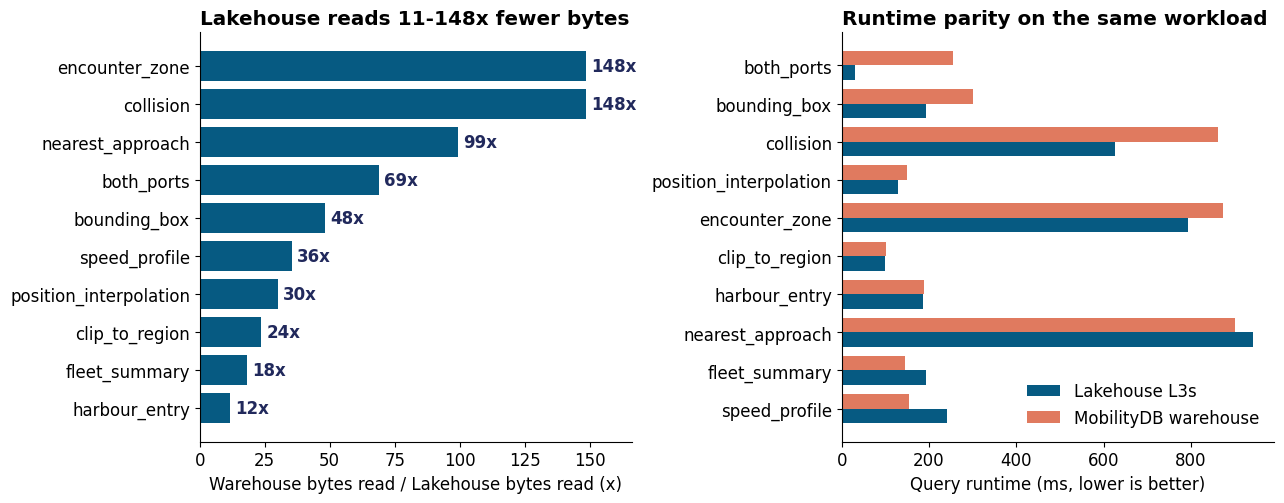

In [8]:
import os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

DEEP, WARM, MID = '#065A82', '#E07A5F', '#21295C'
plt.rcParams.update({'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False})

b = pd.read_csv('results/tab_bytes_lakehouse_vs_warehouse.csv').sort_values('wh_over_L3s')
r = pd.read_csv('results/l3s_lakehouse_vs_l0_warehouse.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

# --- left: bytes-read advantage ---
bars = ax1.barh(b['query'], b['wh_over_L3s'], color=DEEP)
for bar, v in zip(bars, b['wh_over_L3s']):
    ax1.text(v + 2, bar.get_y() + bar.get_height()/2, f'{v:.0f}x', va='center', fontweight='bold', color=MID)
ax1.set_xlabel('Warehouse bytes read / Lakehouse bytes read (x)')
ax1.set_title('Lakehouse reads 11-148x fewer bytes', fontweight='bold', loc='left')
ax1.set_xlim(0, b['wh_over_L3s'].max() * 1.12)

# --- right: runtime parity ---
r = r.dropna(subset=['warehouse_mdb_ms'])
y = np.arange(len(r)); h = 0.38
ax2.barh(y + h/2, r['l3s_ms'], h, color=DEEP, label='Lakehouse L3s')
ax2.barh(y - h/2, r['warehouse_mdb_ms'], h, color=WARM, label='MobilityDB warehouse')
ax2.set_yticks(y); ax2.set_yticklabels(r['query']); ax2.invert_yaxis()
ax2.set_xlabel('Query runtime (ms, lower is better)')
ax2.set_title('Runtime parity on the same workload', fontweight='bold', loc='left')
ax2.legend(loc='lower right', frameon=False)

fig.tight_layout()
os.makedirs('figs', exist_ok=True)
fig.savefig('figs/warehouse_compare.png', dpi=200, bbox_inches='tight')
plt.show()

## Lakehouse vs warehouse: filter and storage

The two axes measured symmetrically for both systems. Ingestion cost is excluded on
purpose: it was measured for the warehouse only (568 s), and the pipeline that produces
the Parquet is shared by both, so the two sides are not comparable on that axis.

Each system is scored in **both** units rather than in the one that suits it. The GiST
index keeps pace with the layout on rows (2.8x ) but not on bytes (32.8x), because
its pruning unit is a whole voyage held in TOAST: a matched row must be read in full
before the predicate can clip it.

Runs standalone from `results/tab_filter_skip.csv` -- no database or object store needed.


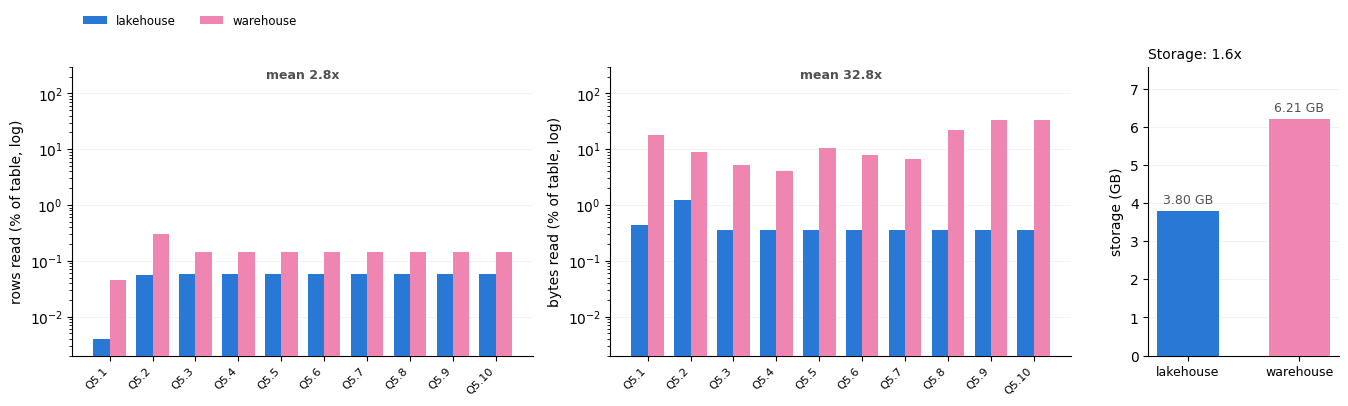

                            Q  lake_rows_read_pct  wh_rows_read_pct  rows_x  lake_bytes_read_pct  wh_bytes_read_pct  bytes_x
query                                                                                                                       
both_ports               Q5.1              0.0039            0.0456    11.7                0.444             18.188     40.9
harbour_entry            Q5.2              0.0567            0.2984     5.3                1.224              8.712      7.1
clip_to_region           Q5.3              0.0589            0.1417     2.4                0.359              5.240     14.6
fleet_summary            Q5.4              0.0589            0.1417     2.4                0.359              4.023     11.2
bounding_box             Q5.5              0.0589            0.1417     2.4                0.359             10.676     29.7
speed_profile            Q5.6              0.0589            0.1417     2.4                0.359              7.851     21.9


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from lakehouse.query.qnames import qnum, sort_key

LAKE, WH = "#2a78d6", "#ef85b1"          # validated categorical pair
d = pd.read_csv("results/tab_filter_skip.csv").set_index("query")
d = d.loc[sorted(d.index, key=sort_key)]
Q = [qnum(q) for q in d.index]
lake_rows, wh_rows = 100 - d.lake_rows_skip, 100 - d.wh_rows_skip
lake_by,   wh_by   = 100 - d.lake_bytes_skip, 100 - d.wh_bytes_skip
LAKE_GB, WH_GB = 3.803, 6.210

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.2),
                         gridspec_kw={"width_ratios": [1.5, 1.5, 0.62]})
x = np.arange(len(d)); w = 0.38
for ax, (lv, wv, name) in zip(axes[:2],
                              [(lake_rows, wh_rows, "rows read"),
                               (lake_by, wh_by, "bytes read")]):
    ax.bar(x - w/2, lv, w, color=LAKE, label="lakehouse", zorder=3)
    ax.bar(x + w/2, wv, w, color=WH, label="warehouse", zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(Q, rotation=45, ha="right", fontsize=8)
    # floor must sit below the smallest bar (Q4.1 lakehouse reads 0.0039% of rows)
    ax.set_yscale("log"); ax.set_ylim(0.002, 300)
    ax.set_ylabel(f"{name} (% of table, log)")
    ax.grid(axis="y", alpha=0.2, lw=0.5); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.annotate(f"mean {wv.mean()/lv.mean():.1f}x", (0.5, 0.96),
                xycoords="axes fraction", ha="center", fontsize=9,
                fontweight="bold", color="#52514e")
# axes[0].set_title("Filter, per query: index keeps pace on rows", loc="left", fontsize=10)
# axes[1].set_title("...but not on bytes", loc="left", fontsize=10)
axes[0].legend(frameon=False, fontsize=8.5, ncol=2, loc="lower left",
               bbox_to_anchor=(0.0, 1.10))

a3 = axes[2]
bars = a3.bar([0, 1], [LAKE_GB, WH_GB], 0.55, color=[LAKE, WH], zorder=3)
a3.bar_label(bars, fmt="%.2f GB", padding=3, fontsize=9, color="#52514e")
a3.set_xticks([0, 1]); a3.set_xticklabels(["lakehouse", "warehouse"], fontsize=9)
a3.set_ylabel("storage (GB)"); a3.set_ylim(0, WH_GB * 1.22)
a3.set_title(f"Storage: {WH_GB/LAKE_GB:.1f}x", loc="left", fontsize=10)
a3.grid(axis="y", alpha=0.2, lw=0.5); a3.set_axisbelow(True)
for s in ("top", "right"): a3.spines[s].set_visible(False)

plt.tight_layout()
fig.savefig("figures/lakehouse_vs_warehouse.png", dpi=200, bbox_inches="tight")
plt.show()

t = pd.DataFrame({"Q": Q, "lake_rows_read_pct": lake_rows.round(4).values,
                  "wh_rows_read_pct": wh_rows.round(4).values,
                  "rows_x": (wh_rows/lake_rows).round(1).values,
                  "lake_bytes_read_pct": lake_by.round(3).values,
                  "wh_bytes_read_pct": wh_by.round(3).values,
                  "bytes_x": (wh_by/lake_by).round(1).values}, index=d.index)
t.to_csv("results/tab_lakehouse_vs_warehouse.csv")
print(t.to_string())
print(f"\nmean rows {wh_rows.mean()/lake_rows.mean():.1f}x | "
      f"mean bytes {wh_by.mean()/lake_by.mean():.1f}x | storage {WH_GB/LAKE_GB:.1f}x")
